In [5]:
%matplotlib widget
from lines import REDUC_LINES
from corr import REDSHIFT, SPECTRALDATA, CONTINUUM_SUBSTRACT
from new_lines import fitting_lines, a_ratio_dist, save_data, fit_auroral_new, save_data_auroral_MC

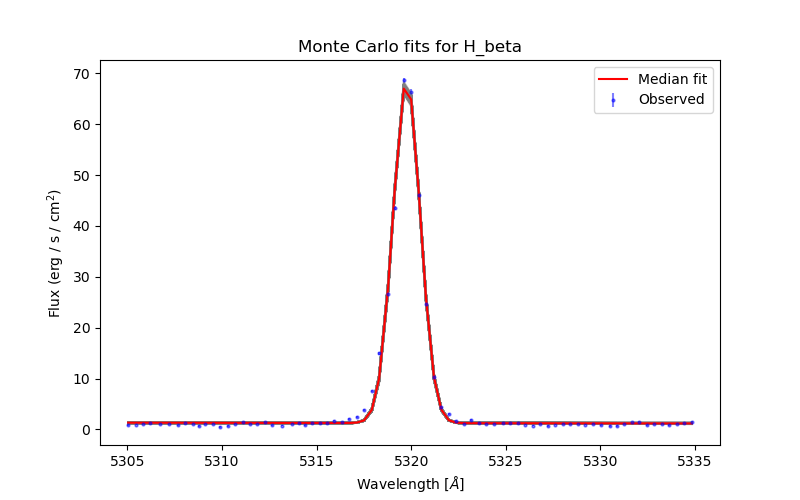

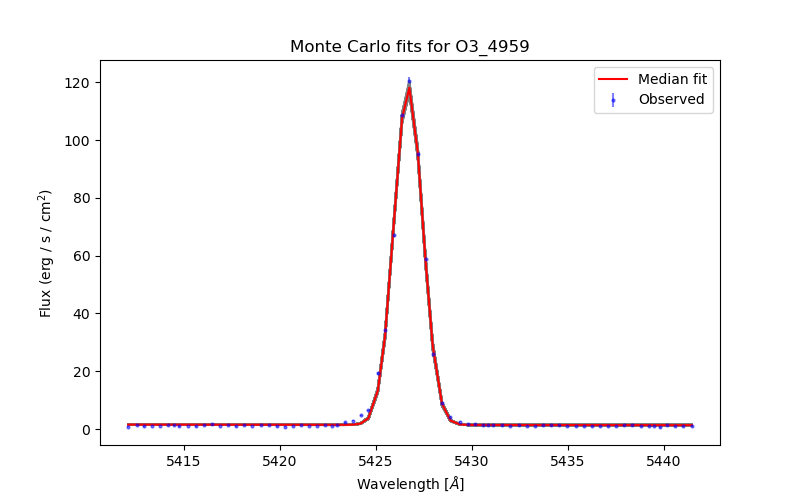

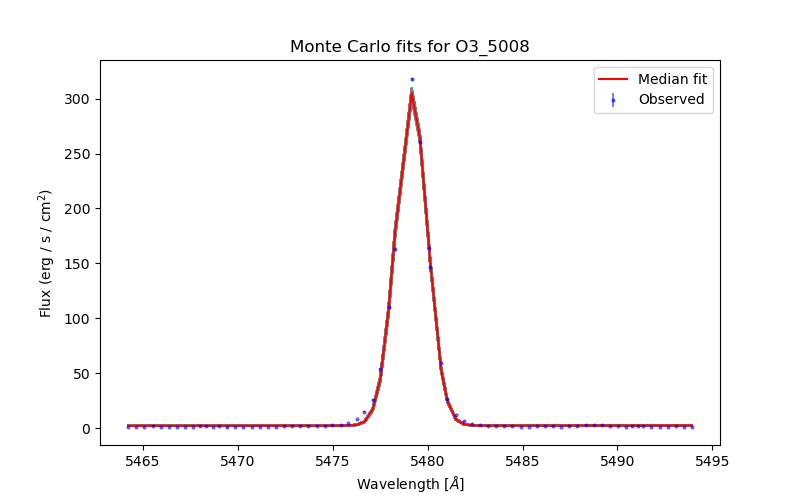

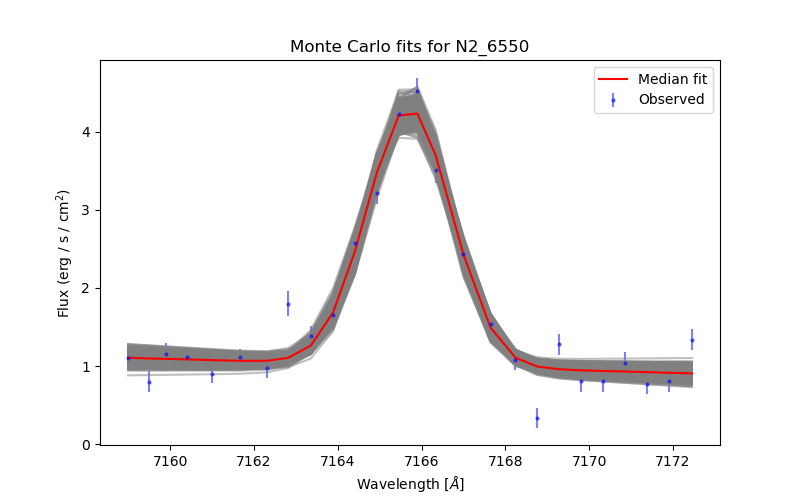

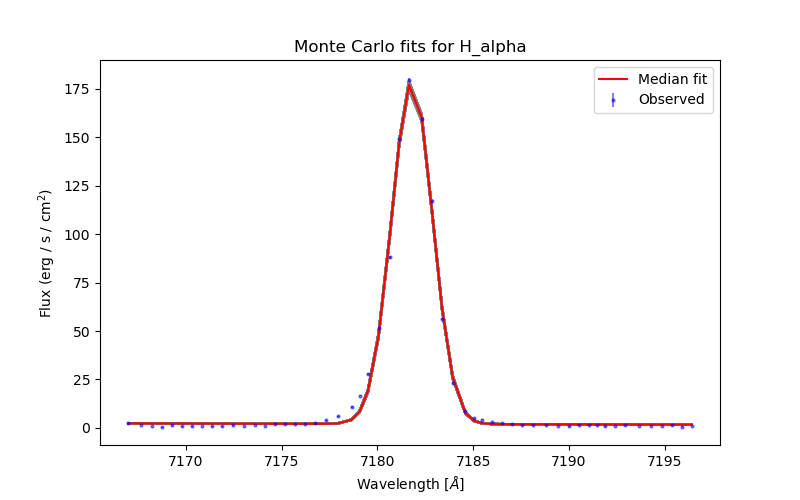

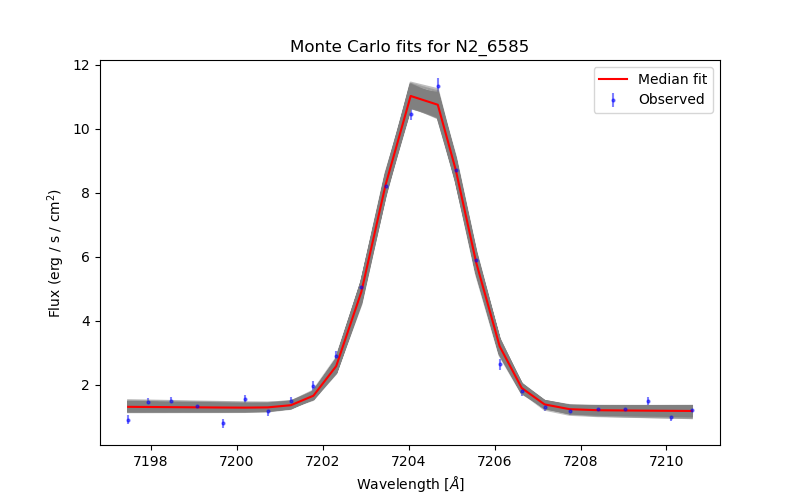

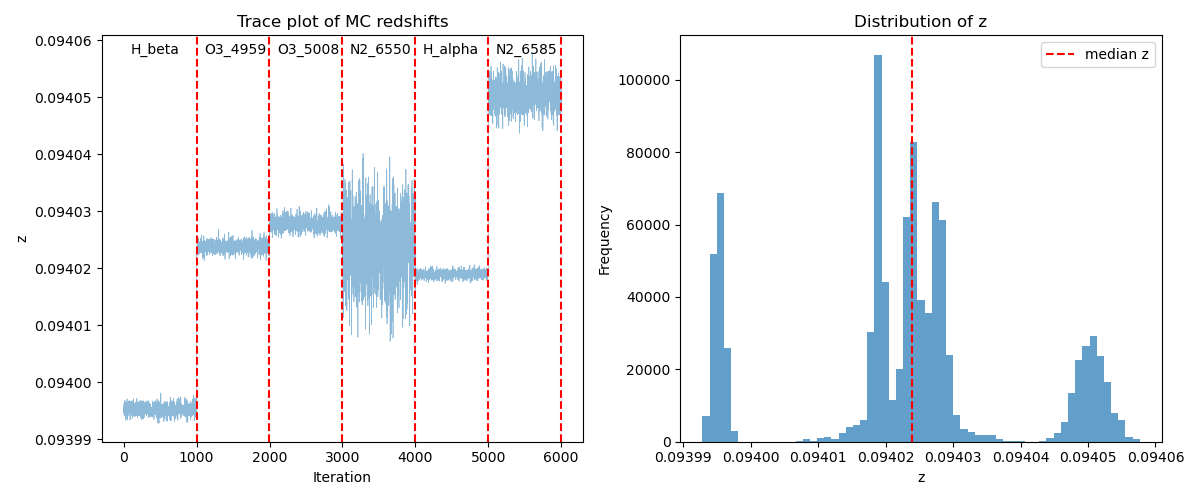

New redshift calculated for twilight,z = 0.09402383996388664
Executed reset_redshift in 39.6896s
New redshift for J2258+0056,z = 0.09402383996388664
Reading data for J2258
Using MW dust + Balmer abs corrected and continuum substracted data
Starting MC iteration
bright
bright done
faint


KeyboardInterrupt: 

In [3]:
from fit_lines import save_data
J2258_SPECTRA= {
    'DIR':'/Users/javieratoro/Desktop/thesis/BAADE_DATA/testing/6-J2258/',
    'FILES': ['twilight/J2258_TWILIGHT_tellcorr.fits'], #'no_very_flats/J2258_NO_VERY_FLATS_tellcorr.fits'],
     'redshift': 0.094,
     'names':['J2258+0056'],
     'mass':9.6
}
save_data(J2258_SPECTRA, 100)

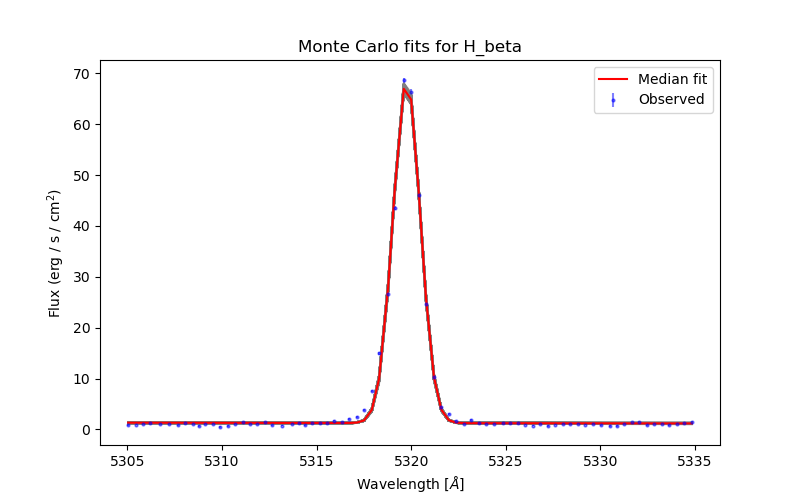

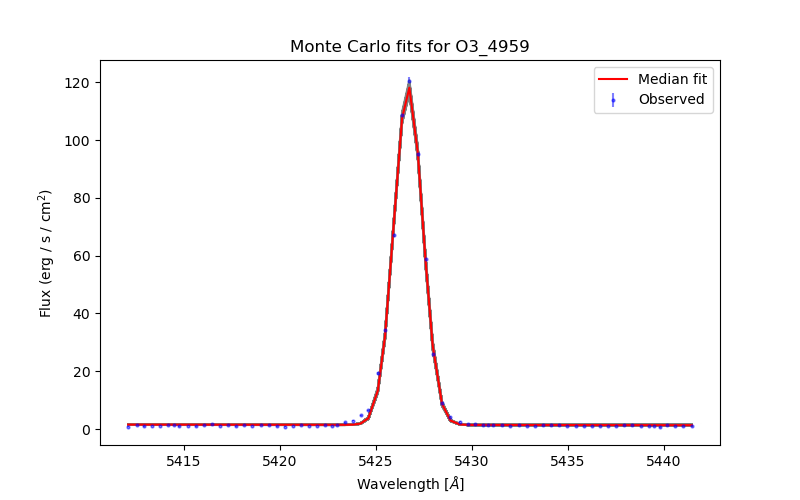

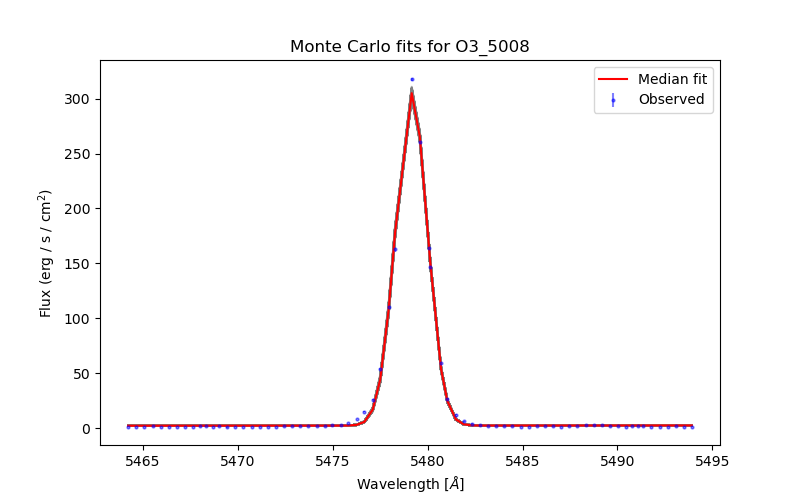

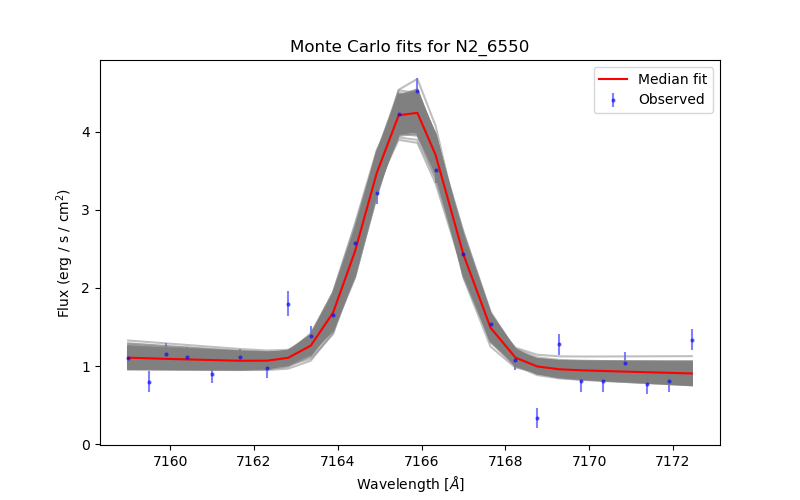

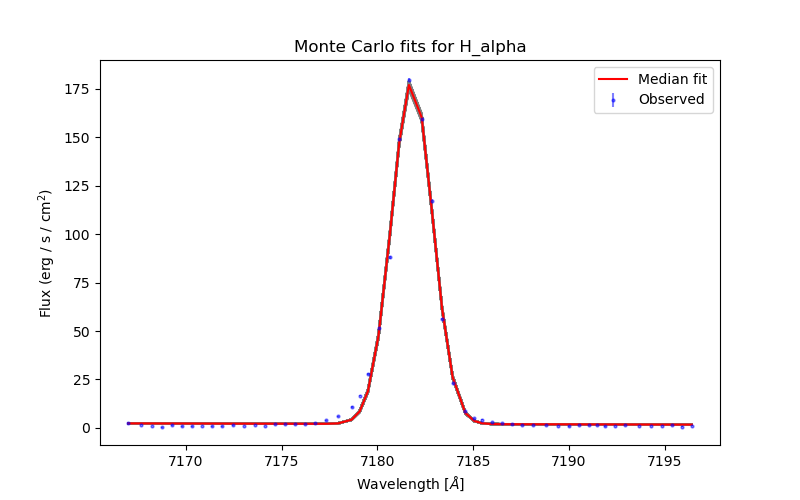

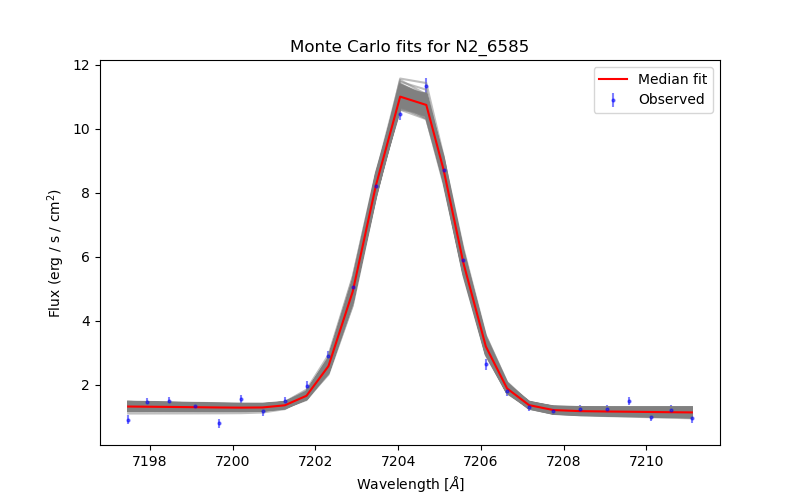

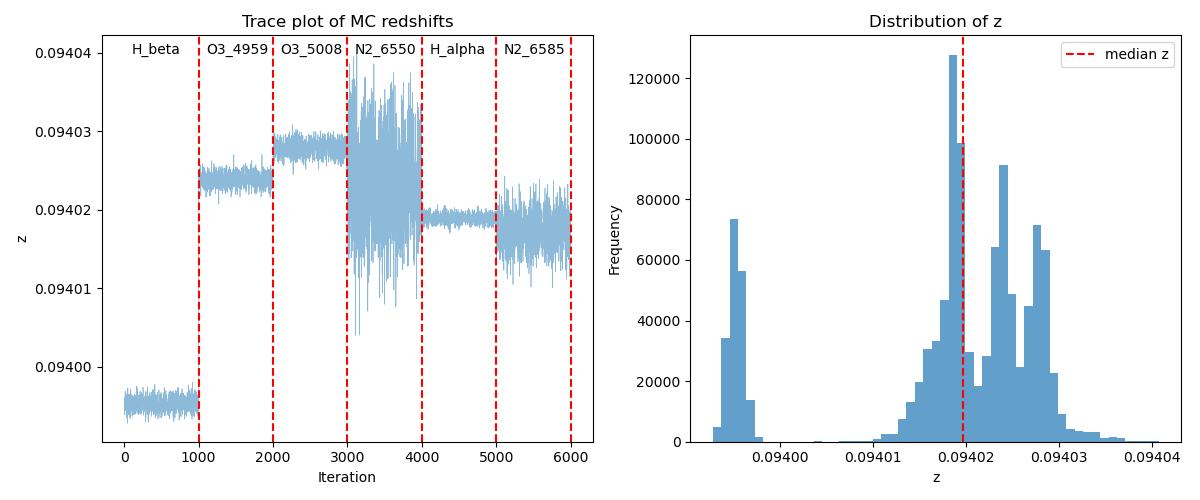

New redshift calculated for twilight,z = 0.09401968938999028
Executed reset_redshift in 44.9881s
New redshift for J2258+0056,z = 0.09401968938999028


In [2]:
J2258_SPECTRA= {
    'DIR':'/Users/javieratoro/Desktop/thesis/BAADE_DATA/testing/6-J2258/',
    'FILES': ['twilight/J2258_TWILIGHT_tellcorr.fits'], #'no_very_flats/J2258_NO_VERY_FLATS_tellcorr.fits'],
     'redshift': 0.094,
     'names':['J2258+0056'],
     'mass':9.6
}
J2258 = SPECTRALDATA(J2258_SPECTRA)
Z = REDSHIFT(J2258)

Reading data for J2258
Using MW dust + Balmer abs corrected and continuum substracted data


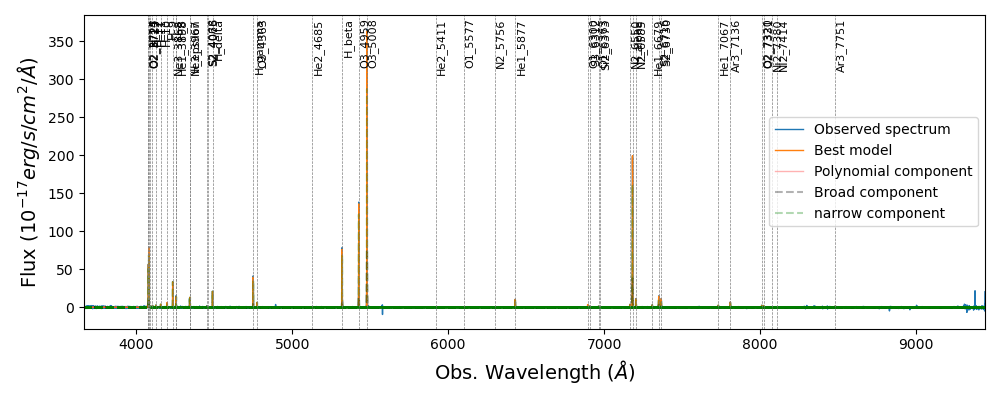

In [3]:
red = REDUC_LINES(J2258)
fit = red.fit_spectra(show_Plot=True)

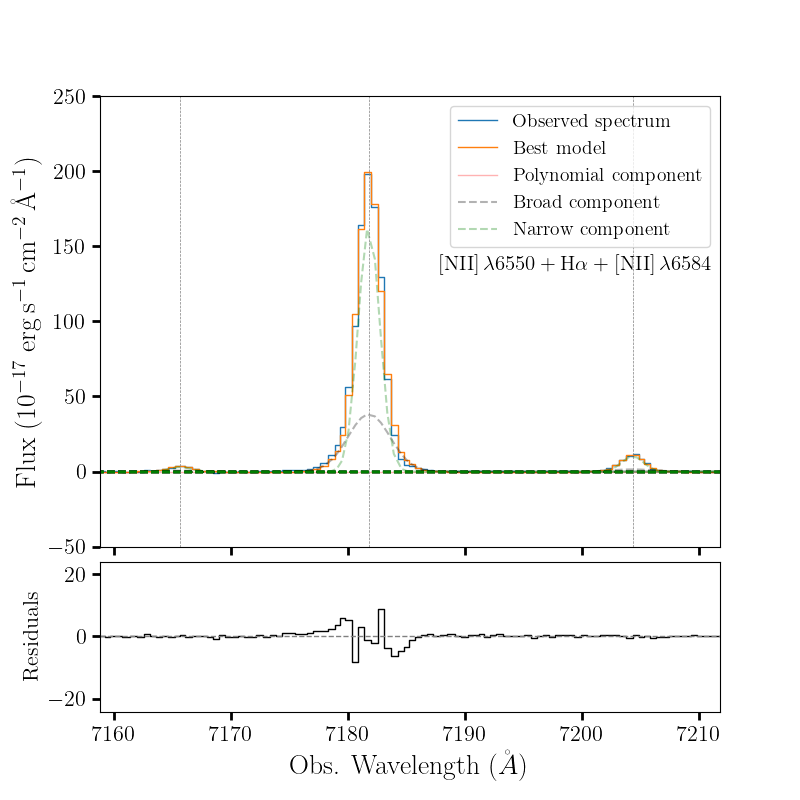

In [6]:
# red = REDUC_LINES(J0136)
# fit = red.fit_spectra(show_Plot=True)
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"

fig2, (ax, ax_res) = plt.subplots(
    2, 1, figsize=(8, 8),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}
)

comps = fit.eval_components(x=red.wave)

# --- Main spectrum ---
narrow_key = [key for key, _ in comps.items() if 'narrow' in key]

ax.plot(red.wave, red.flux, lw=1, drawstyle='steps-mid',
        label='Observed spectrum')

ax.plot(red.wave, fit.best_fit, lw=1, drawstyle='steps-mid',
        label='Best model')

ax.plot(red.wave, comps['polynomial'], 'r-',
        label='Polynomial component',
        lw=1, drawstyle='steps-mid', alpha=0.3)

broad_key = [key for key, _ in comps.items() if 'broad' in key]

for i, broad_line in enumerate(broad_key):
    ax.plot(red.wave, comps[broad_line] + comps['polynomial'],
            'k--',
            label='Broad component' if i == len(broad_key)-1 else None,
            alpha=0.3)

for i, narrow_line in enumerate(narrow_key):
    ax.plot(red.wave, comps[narrow_line] + comps['polynomial'],
            'g--',
            label='Narrow component' if i == len(narrow_key)-1 else None,
            alpha=0.3)


# --- Residuals ---
residuals = red.flux - fit.best_fit

ax_res.plot(red.wave, residuals,
            color='black',
            lw=1,
            drawstyle='steps-mid')

ax_res.axhline(0, color='grey', linestyle='--', lw=1)

ax_res.set_ylabel('Residuals', size=16)
ax_res.set_xlabel(r'Obs. Wavelength ($\AA$)', size=20)
# ax_res.set_ylim(-40, 40)


# --- Emission line markers ---
for label in red.spectra.linelist_dict.keys():
    obs_lam = red.spectra.linelist_dict[label] * (1 + red.spectra.redshift)

    ax.axvline(obs_lam, linestyle='--',
               linewidth=0.5, color='grey')


ax.text(0.99, 0.65,
    r'$[\mathrm{NII}]\,\lambda6550 + \mathrm{H\alpha} +[\mathrm{NII}]\,\lambda6584$',
    transform=ax.transAxes,
    fontsize=15,
    color='k',
    ha='right',
    va='top'
)
# --- Formatting ---
ax.set_ylabel(r'Flux ($10^{-17}\ \mathrm{erg\,s^{-1}\,cm^{-2}\,\AA^{-1}}$)', size=20)
obs_lam = red.spectra.linelist_dict['H_alpha'] * (1 + red.spectra.redshift)
ax.set_xlim(obs_lam-23, obs_lam+30)
ax.set_ylim(-50, 250)

ax.legend(fontsize=14, frameon=True, loc='upper right')
ax_res.tick_params(
    axis='both',
    which='major',
    labelsize=16,
    width=2,
    length=6
)
ax.tick_params(
    axis='both',
    which='major',
    labelsize=16,
    width=2,
    length=6, labelbottom=False
)


plt.show()

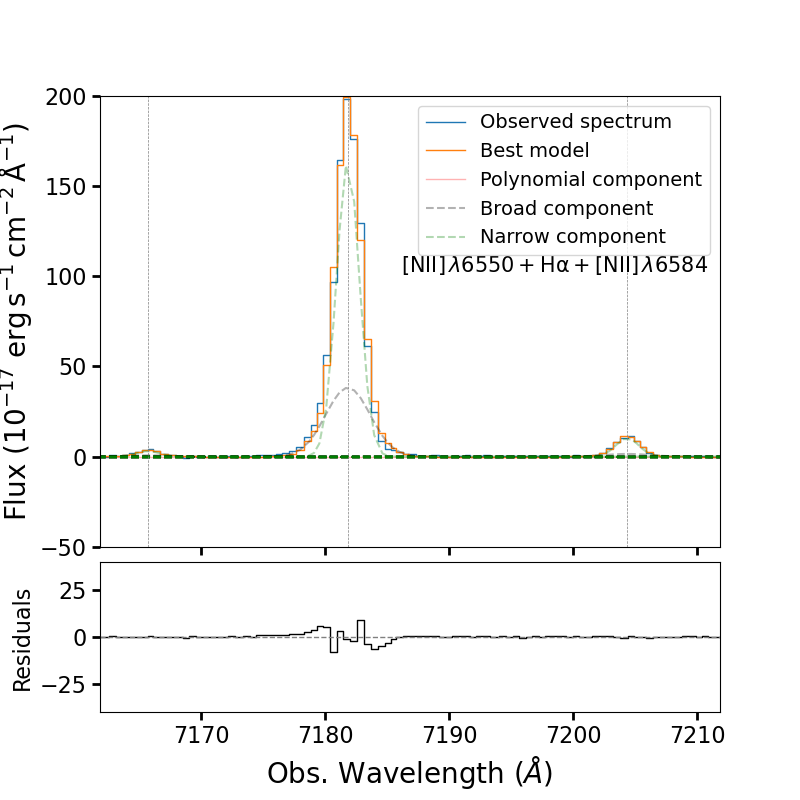

In [4]:
import matplotlib.pyplot as plt
fig2, (ax, ax_res) = plt.subplots(
    2, 1, figsize=(8, 8),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}
)

comps = fit.eval_components(x=red.wave)

# --- Main spectrum ---
narrow_key = [key for key, _ in comps.items() if 'narrow' in key]

ax.plot(red.wave, red.flux, lw=1, drawstyle='steps-mid',
        label='Observed spectrum')

ax.plot(red.wave, fit.best_fit, lw=1, drawstyle='steps-mid',
        label='Best model')

ax.plot(red.wave, comps['polynomial'], 'r-',
        label='Polynomial component',
        lw=1, drawstyle='steps-mid', alpha=0.3)

broad_key = [key for key, _ in comps.items() if 'broad' in key]

for i, broad_line in enumerate(broad_key):
    ax.plot(red.wave, comps[broad_line] + comps['polynomial'],
            'k--',
            label='Broad component' if i == len(broad_key)-1 else None,
            alpha=0.3)

for i, narrow_line in enumerate(narrow_key):
    ax.plot(red.wave, comps[narrow_line] + comps['polynomial'],
            'g--',
            label='Narrow component' if i == len(narrow_key)-1 else None,
            alpha=0.3)


# --- Residuals ---
residuals = red.flux - fit.best_fit

ax_res.plot(red.wave, residuals,
            color='black',
            lw=1,
            drawstyle='steps-mid')

ax_res.axhline(0, color='grey', linestyle='--', lw=1)

ax_res.set_ylabel('Residuals', size=16)
ax_res.set_xlabel(r'Obs. Wavelength ($\AA$)', size=20)
ax_res.set_ylim(-40, 40)


# --- Emission line markers ---
for label in red.spectra.linelist_dict.keys():
    obs_lam = red.spectra.linelist_dict[label] * (1 + red.spectra.redshift)

    ax.axvline(obs_lam, linestyle='--',
               linewidth=0.5, color='grey')


ax.text(0.98, 0.65,
    r'$[\mathrm{NII}]\,\lambda6550 + \mathrm{H\alpha} +[\mathrm{NII}]\,\lambda6584$',
    transform=ax.transAxes,
    fontsize=15,
    color='k',
    ha='right',
    va='top'
)
# --- Formatting ---
ax.set_ylabel(r'Flux ($10^{-17}\ \mathrm{erg\,s^{-1}\,cm^{-2}\,\AA^{-1}}$)', size=20)
obs_lam = red.spectra.linelist_dict['H_alpha'] * (1 + red.spectra.redshift)
ax.set_xlim(obs_lam-20, obs_lam+30)
ax.set_ylim(-50, 200)

ax.legend(fontsize=14, frameon=True, loc='upper right')
ax_res.tick_params(
    axis='both',
    which='major',
    labelsize=16,
    width=2,
    length=6
)
ax.tick_params(
    axis='both',
    which='major',
    labelsize=16,
    width=2,
    length=6, labelbottom=False
)


plt.show()

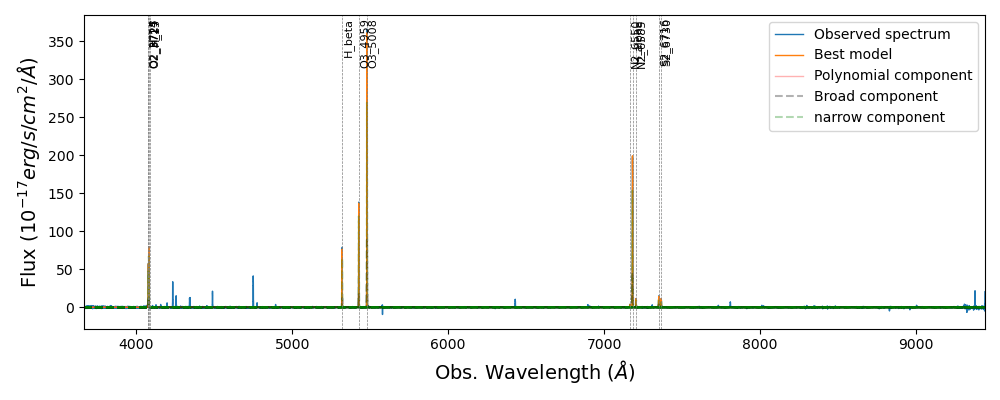

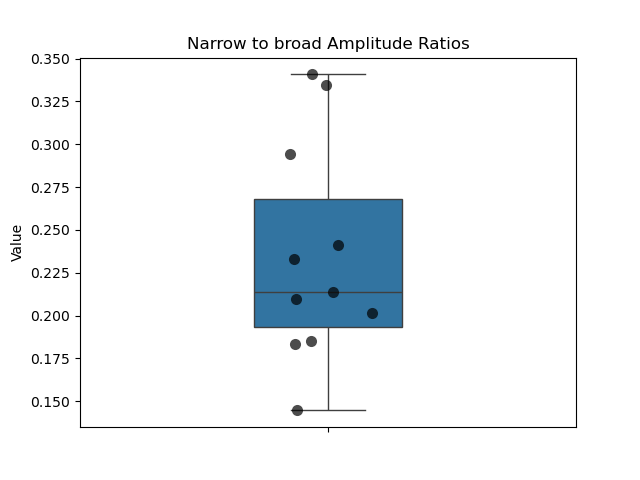

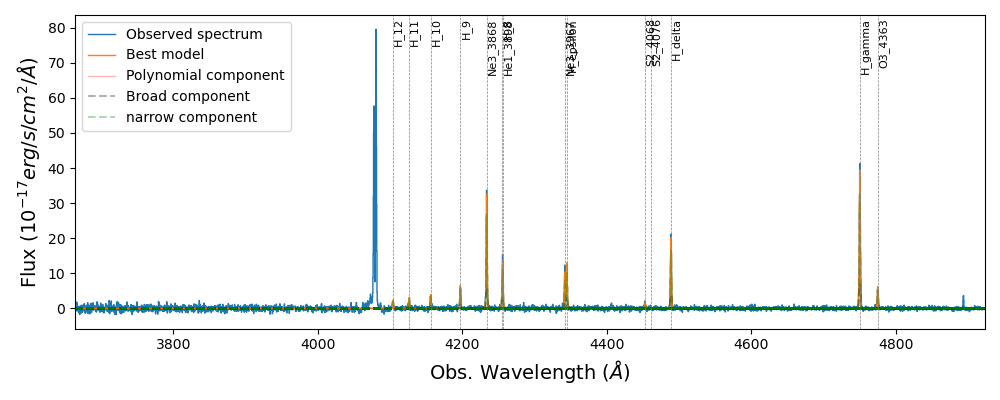

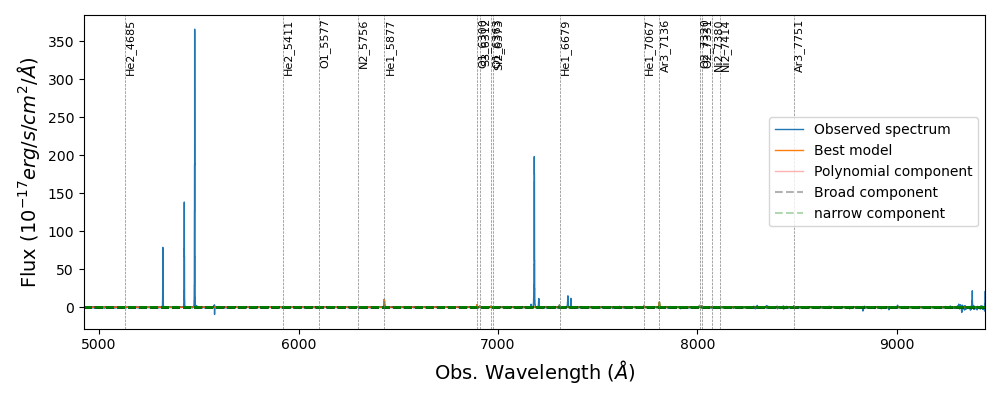

In [4]:
linelist = red.spectra.linelist_dict
bright_lines = ['H_14', 'H_13', 'O2_3725', 'O2_3727', 'H_alpha', 'H_beta',
                'O3_5008', 'O3_4959', 'N2_6550', 'N2_6585',
                'S2_6716','S2_6730']

bright_dict = {k: v for k, v in linelist.items() if k in bright_lines}
faint_dict  = {k: v for k, v in linelist.items() if k not in bright_lines}

mask = (red.wave < 4500*(1+red.spectra.redshift))
wave1, flux1, sigma1 = red.wave[mask], red.flux[mask], red.sigma[mask]
wave2, flux2, sigma2 = red.wave[~mask], red.flux[~mask], red.sigma[~mask]

blue_lines_b = {k:v for k,v in bright_dict.items() if v < 4500}
red_lines_b  = {k:v for k,v in bright_dict.items() if v >= 4500}

blue_lines_f = {k:v for k,v in faint_dict.items() if v < 4500}
red_lines_f  = {k:v for k,v in faint_dict.items() if v >= 4500}

lines = red.spectra.linelist_dict
blue_lines = {k:v for k,v in lines.items() if v < 4500}
red_lines = {k:v for k,v in lines.items() if v >= 4500}


init = fitting_lines(red.wave, red.flux,
                    bright_dict,
                    z_init=red.spectra.redshift, plot=True,
                    nfev=1000, fit=None, A_ratio=None)
ratios = a_ratio_dist(init, plot=True)

out_blue = fitting_lines(wave1, flux1,
                    blue_lines_f,
                    z_init=red.spectra.redshift, plot=True,
                    nfev=1000, fit=init, A_ratio=ratios)

out_red = fitting_lines(wave2, flux2,
                    red_lines_f,
                    z_init=red.spectra.redshift,plot=True,
                    nfev=1000, fit=init, A_ratio=ratios)

In [5]:
save_data(red, 100)

Starting MC iteration


/opt/anaconda3/envs/pypeit/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/pypeit/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Skipping MC iteration 2
Skipping MC iteration 3
Skipping MC iteration 4


/opt/anaconda3/envs/pypeit/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


Skipping MC iteration 6
Skipping MC iteration 7
Skipping MC iteration 8


...

/opt/anaconda3/envs/pypeit/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


Skipping MC iteration 208


/opt/anaconda3/envs/pypeit/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


Skipping MC iteration 212
Skipping MC iteration 213
Saving in /Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/J2258/


,ID,mass,z_red,z_blue,name,flux,fluxerr,narrow_flux,narrow_fluxerr,broad_flux,broad_fluxerr
0,J2258+0056,9.6,0.094026,0.094035,H_14,12.735580,1.798193,2.038575,0.385574,10.723714,1.712602
1,J2258+0056,9.6,0.094026,0.094035,O2_3725,94.107422,6.950716,75.014277,1.714244,19.382006,6.535818
2,J2258+0056,9.6,0.094026,0.094035,O2_3727,112.648714,5.002043,107.339662,2.279634,4.218138,6.175253
3,J2258+0056,9.6,0.094026,0.094035,H_13,1.237498,0.271859,1.236868,0.271857,0.000120,0.000863
4,J2258+0056,9.6,0.094026,0.094035,H_12,6.257309,0.779658,0.978890,0.272130,5.231381,0.787399
5,J2258+0056,9.6,0.094026,0.094035,H_11,8.678495,0.932520,1.321806,0.346196,7.308768,1.007520
6,J2258+0056,9.6,0.094026,0.094035,H_10,10.422447,0.924207,1.587966,0.415990,8.833793,1.099737
7,J2258+0056,9.6,0.094026,0.094035,H_9,16.937563,1.245726,2.593954,0.712037,14.442699,1.592273
8,J2258+0056,9.6,0.094026,0.094035,Ne3_3868,92.316937,6.983953,13.893569,3.576703,77.441643,8.705503
9,J2258+0056,9.6,0.094026,0.094035,He1_3898,40.522857,3.060383,6.179484,1.472390,34.346623,3.798497


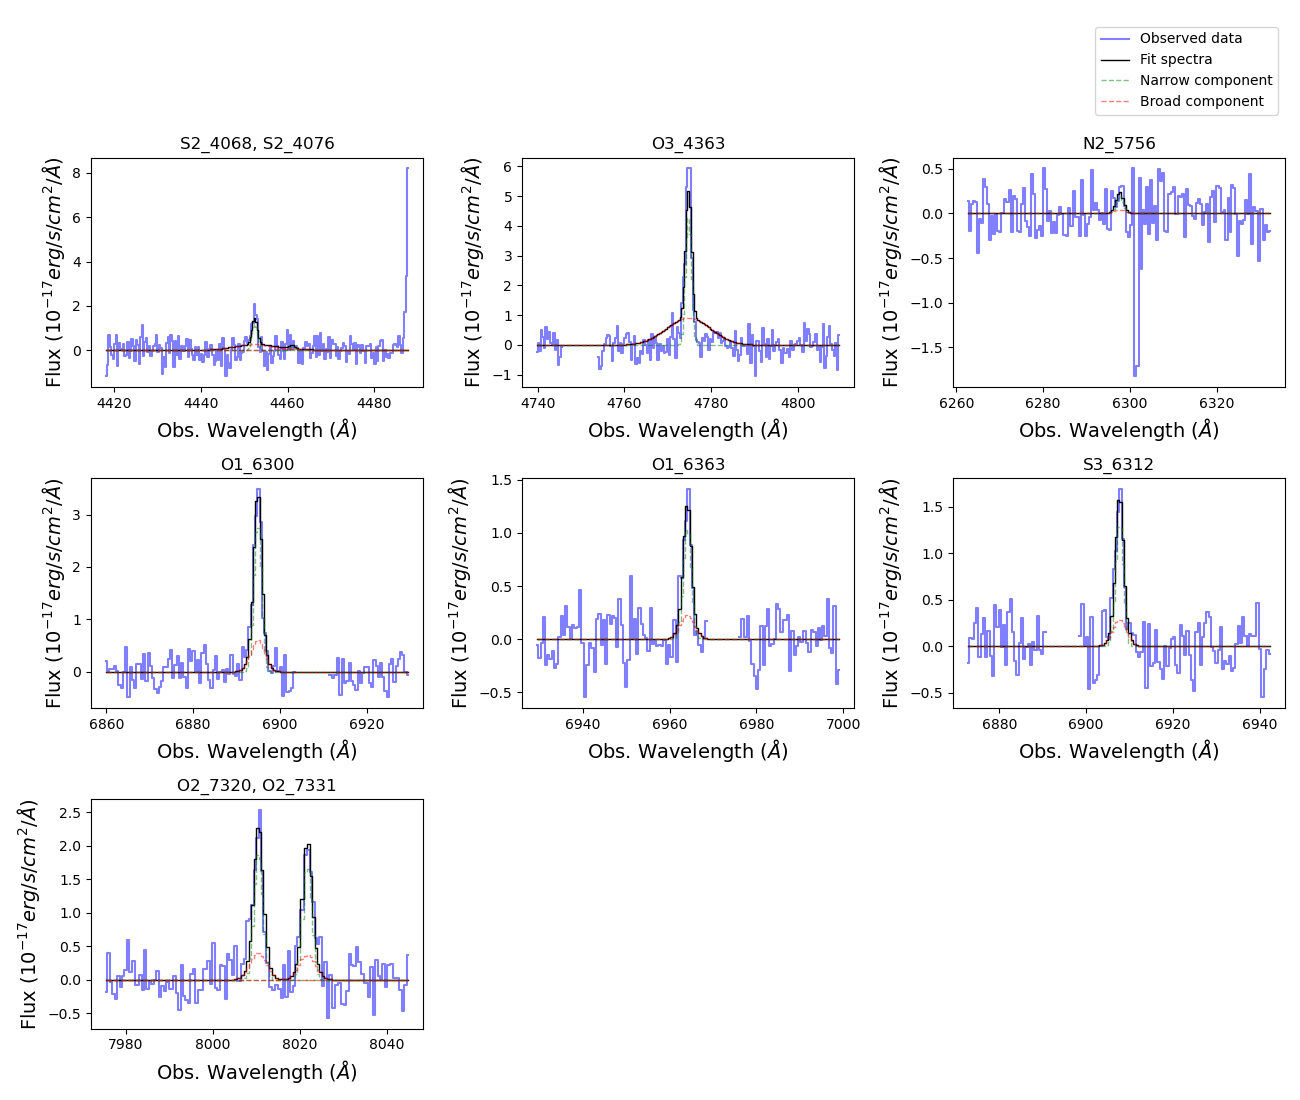

In [8]:
a, b = fit_auroral_new(red, ratio=ratios, flux_=red.flux, showplot=True)

In [9]:
info, res = save_data_auroral_MC(red, ratio=ratios, num=100)

/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/new_lines.py:541: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  yoff = np.random.randn(len(class_.flux)) * class_.sigma


Performing dust correction for J2258
Extinction correction done! Using total curve.


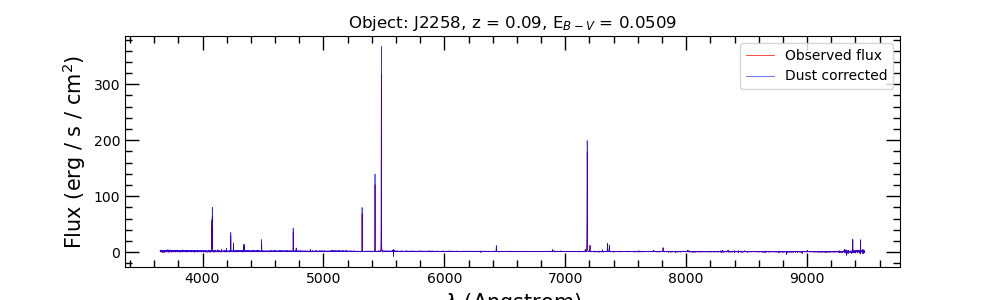

Saved figure at: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/dust/J2258/dcorr_J2258.pdf
Using MW dust + Balmer abs corrected and continuum substracted data


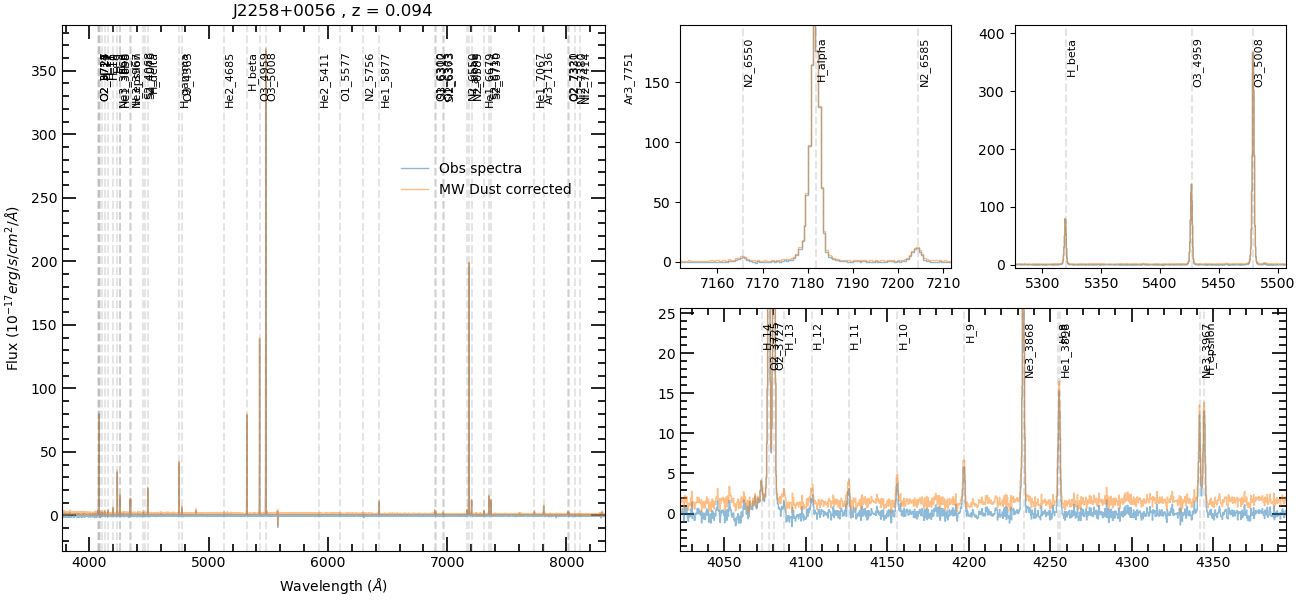

Saved MW dust corrected data to: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/dust/J2258/dcorr_J2258.csv
Executed MW_dust_corr in 0.7476s


In [3]:
MW_DUST_CORR(J2258, plot=True)

Reading data for J2258
Using MW dust corrected data
Performing Balmer absorption correction for J2258


/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/corr.py:465: RuntimeWarning: divide by zero encountered in divide
  weights=1/self.sigma**2,


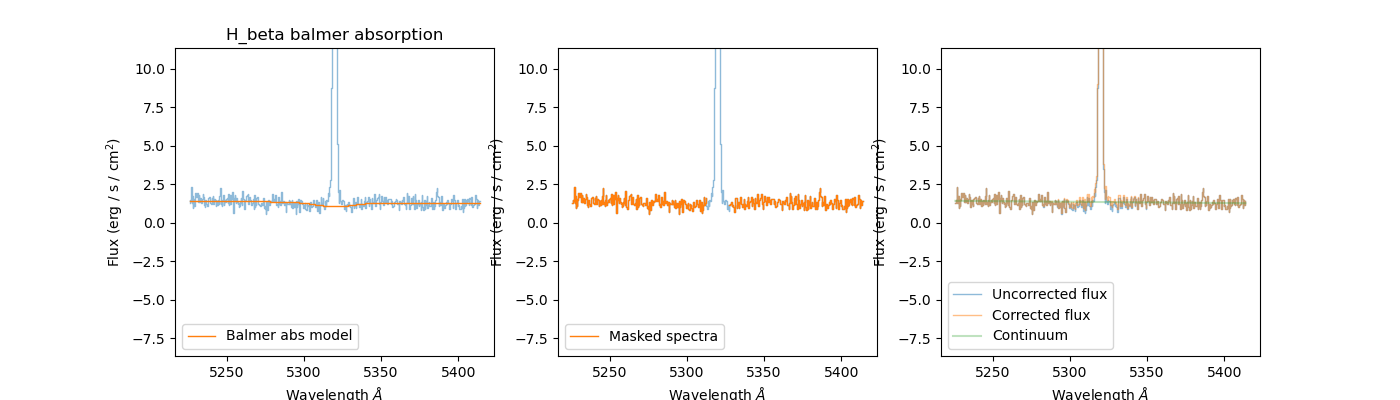

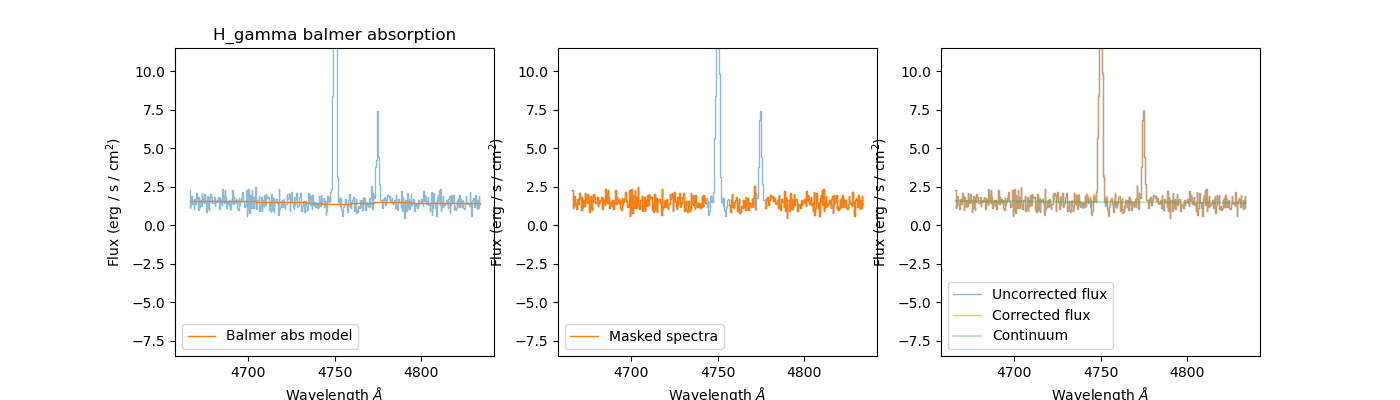

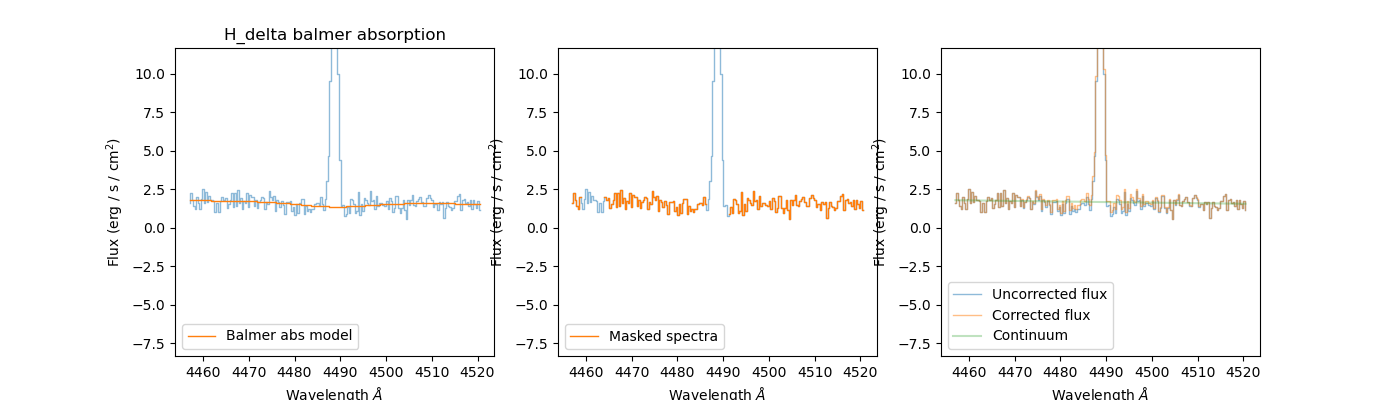

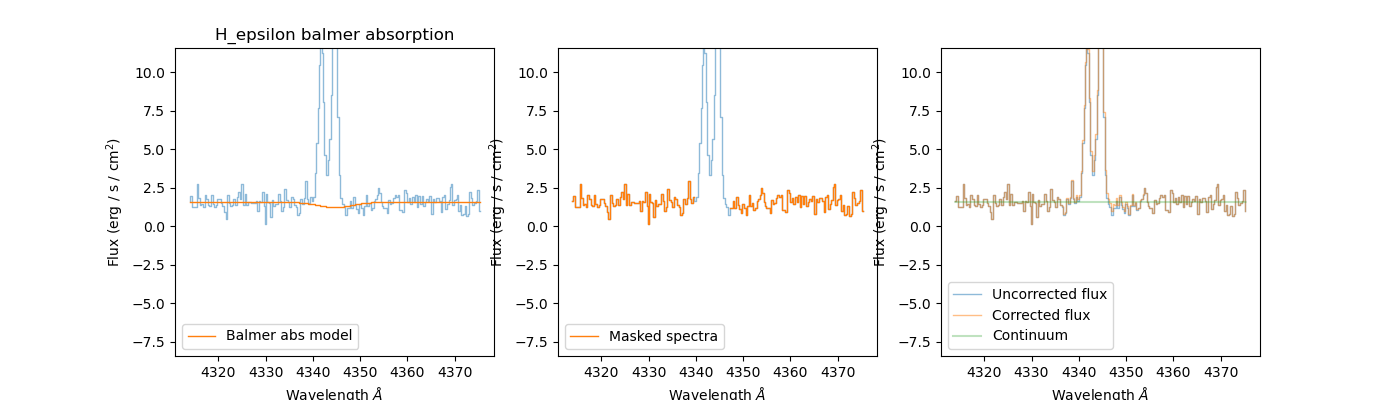

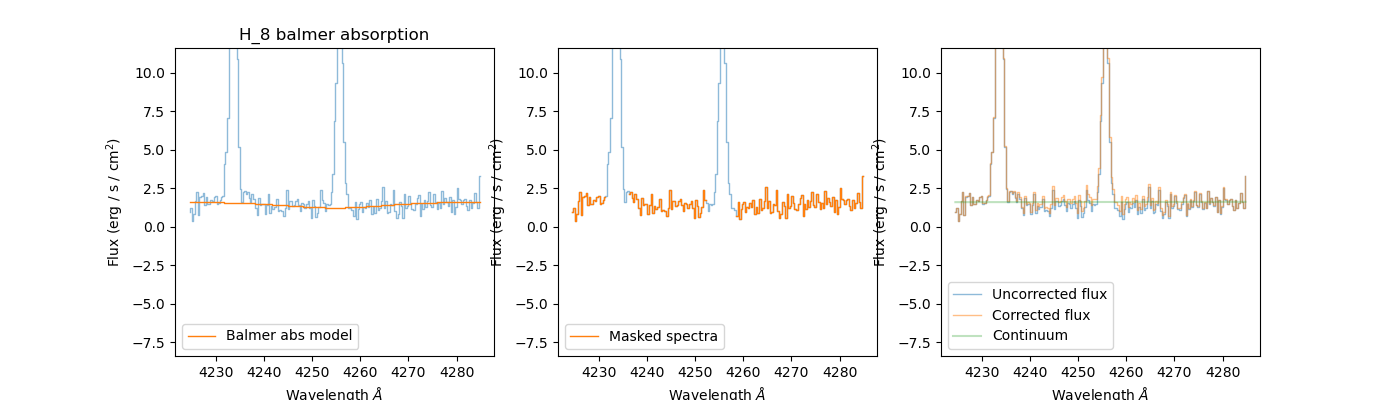

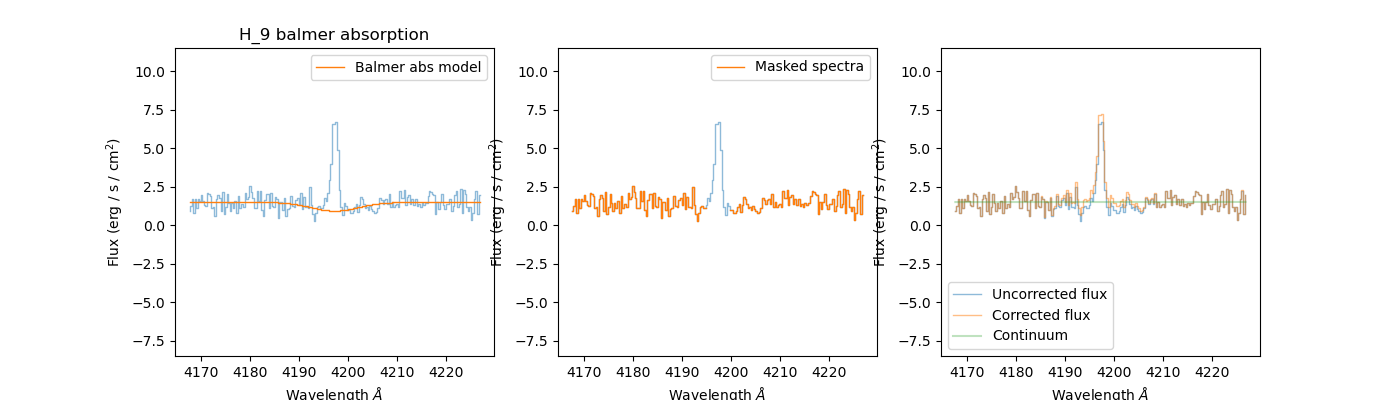

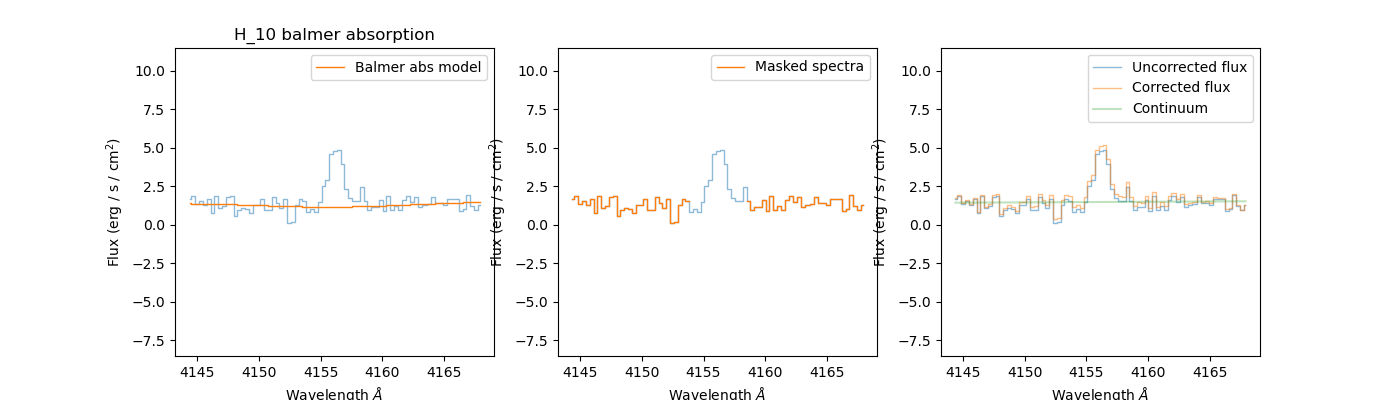

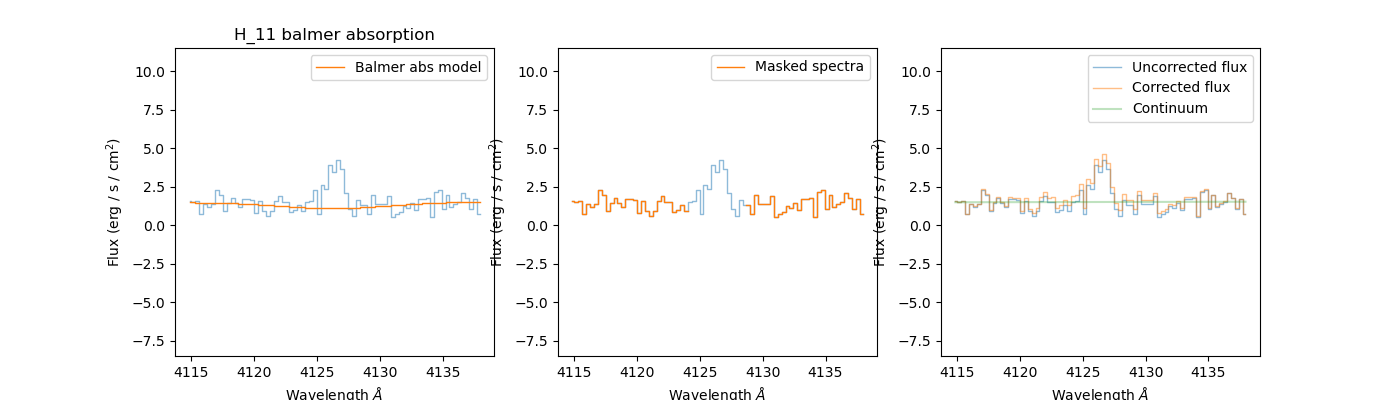

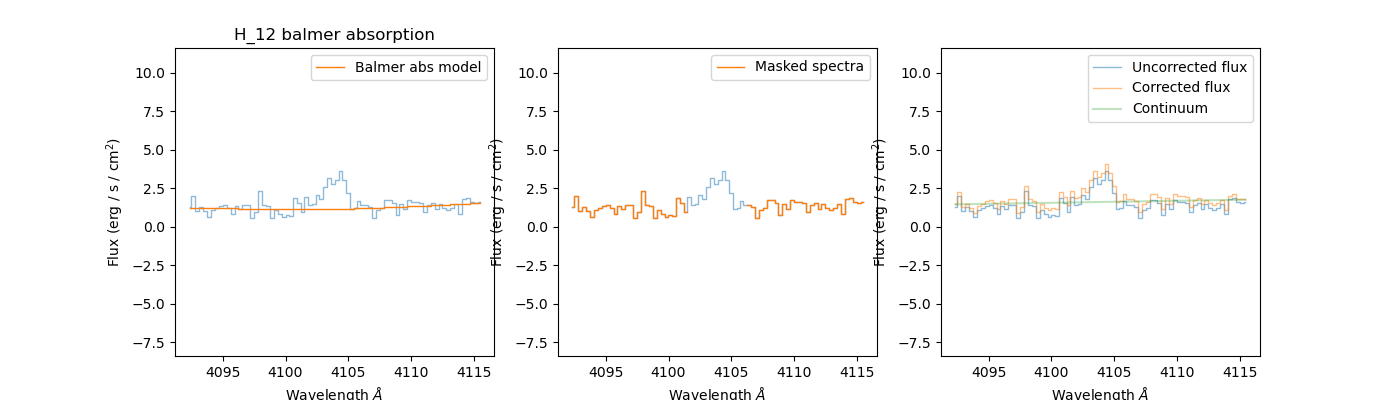

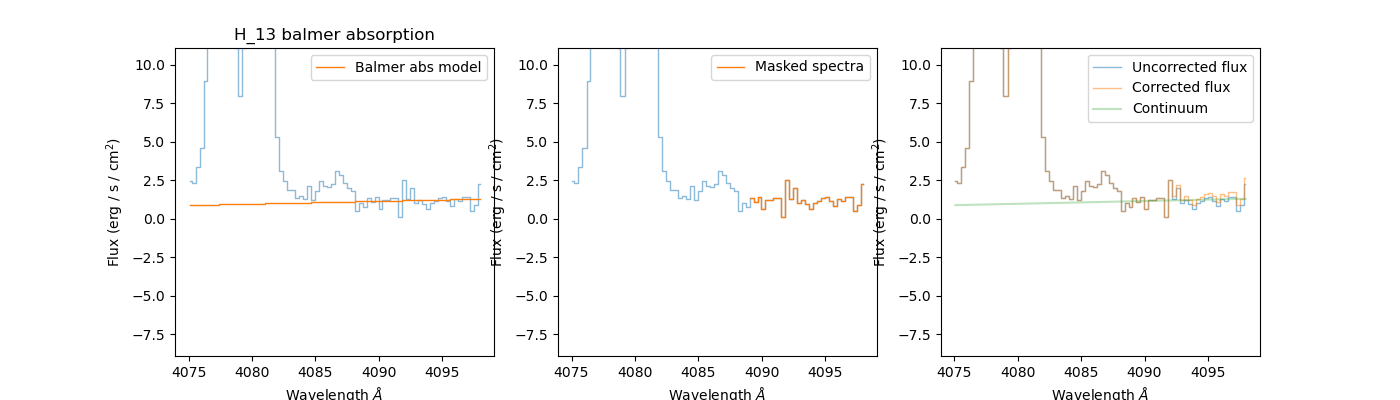

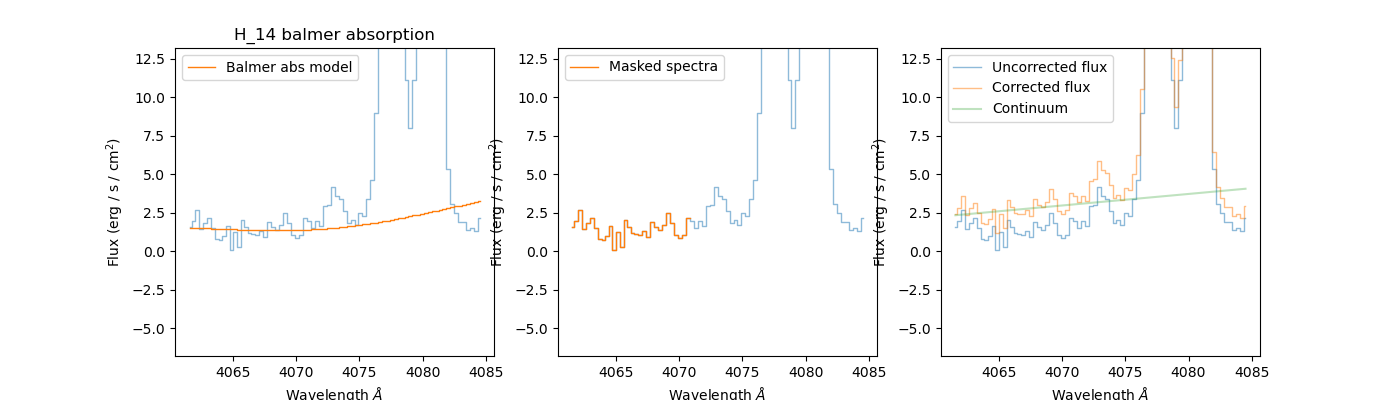

/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/corr.py:744: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(constrained_layout=True, figsize=(13, 6))


Using MW dust + Balmer abs corrected and continuum substracted data


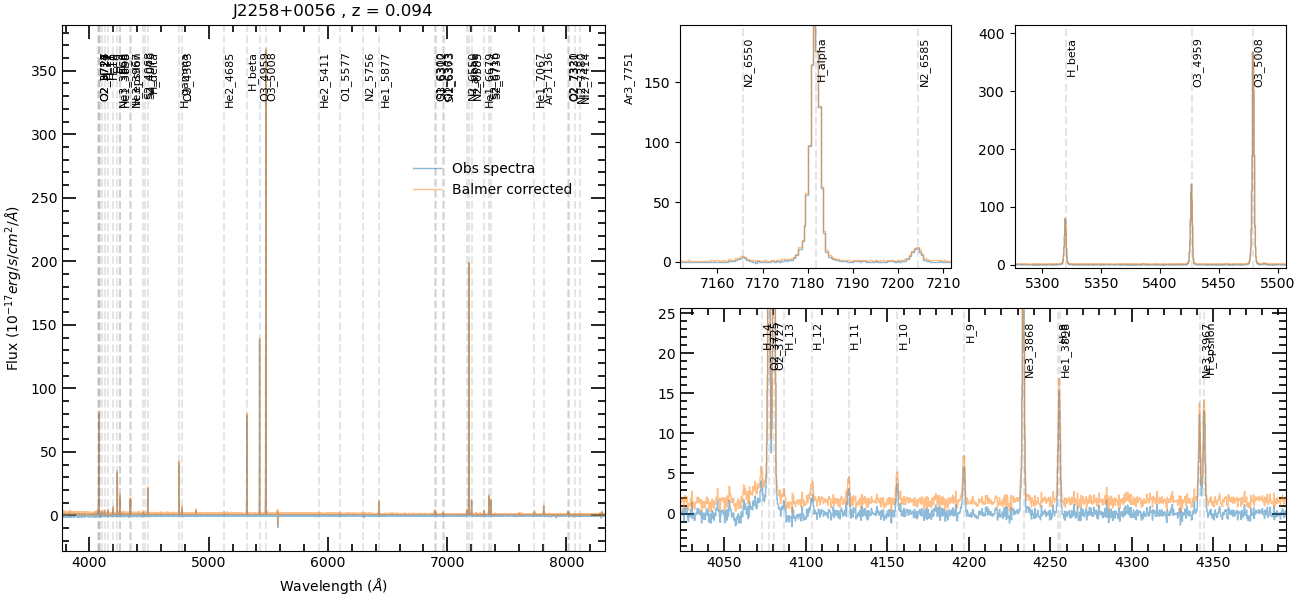

Saved Balmer Absorption corrected data to: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/bal_abs/bcorr_J2258.csv
Balmer absorption correction done!
Executed bal_abs_corr in 13.0836s


In [4]:
b = BALMER_ABS(J2258, showplot=True)

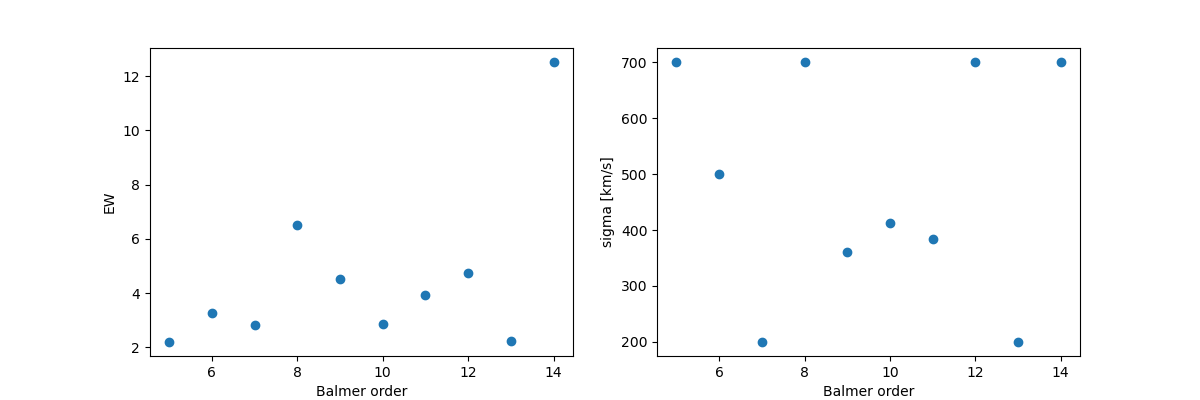

,ID,z,name,sigma,EW
0,J2258+0056,0.094024,H_beta,700.000000,-6.737112
1,J2258+0056,0.094024,H_gamma,700.000000,-2.197959
2,J2258+0056,0.094024,H_delta,499.886054,-3.274525
3,J2258+0056,0.094024,H_epsilon,200.000000,-2.811253
4,J2258+0056,0.094024,H_8,700.000000,-6.502907
5,J2258+0056,0.094024,H_9,360.642240,-4.529284
6,J2258+0056,0.094024,H_10,413.070007,-2.859157
7,J2258+0056,0.094024,H_11,383.561455,-3.925693
8,J2258+0056,0.094024,H_12,699.999214,-4.740905
9,J2258+0056,0.094024,H_13,199.999813,-2.216732


In [5]:
b.EW()

Reading data for J2258
Using MW dust + Balmer abs corrected  data
Executed cont_est in 0.1388s
Using MW dust + Balmer abs corrected and continuum substracted data


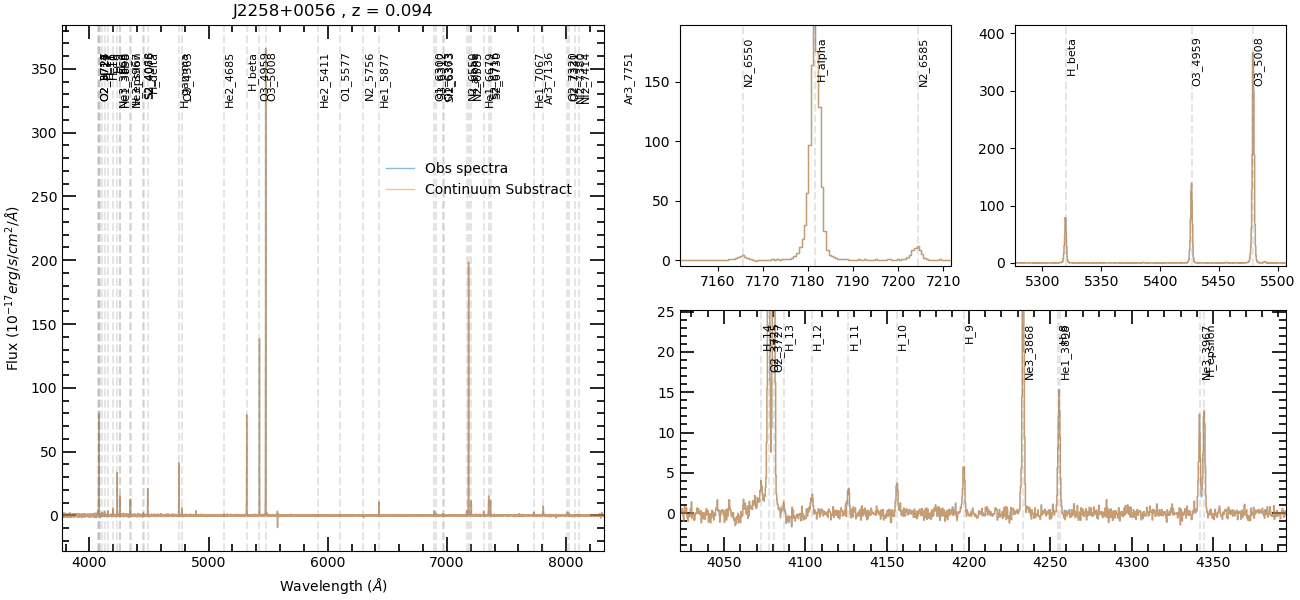

Saved continuum substracted data to: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/cont_subs/J2258/cont_corr_J2258.csv


In [4]:
CONTINUUM_SUBSTRACT(J2258)

Reading data for J2258
Using MW dust + Balmer abs corrected and continuum substracted data


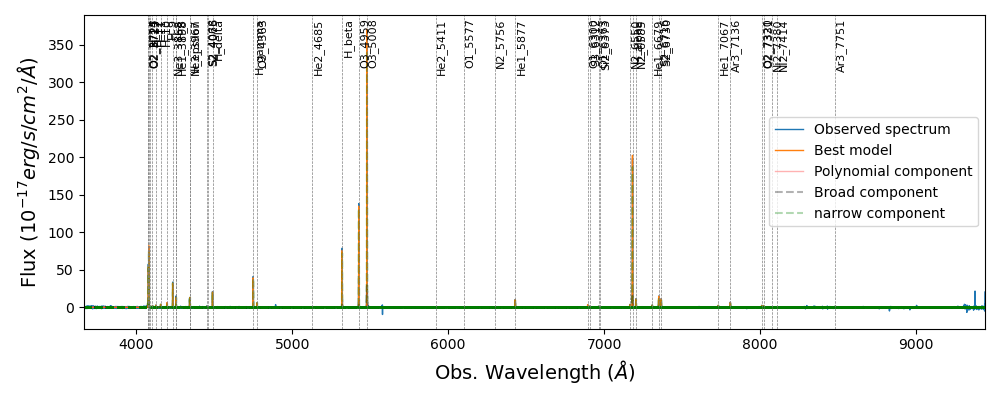

In [3]:
red = REDUC_LINES(J2258)
fit = red.fit_spectra(show_Plot=True)

In [4]:
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['H_alpha']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['H_beta']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['O3_5008']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['O3_4363']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['N2_6550']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['N2_6585']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))

2.579022837952892
1.910402274613935
1.967584420930081
1.714655078447535
2.5732393792009844
2.5871506957555597


In [8]:
red.fit_MC(numMC=100)

Calculating the first initial params
Starting MC iteration
Executed fit_MC in 1123.5481s


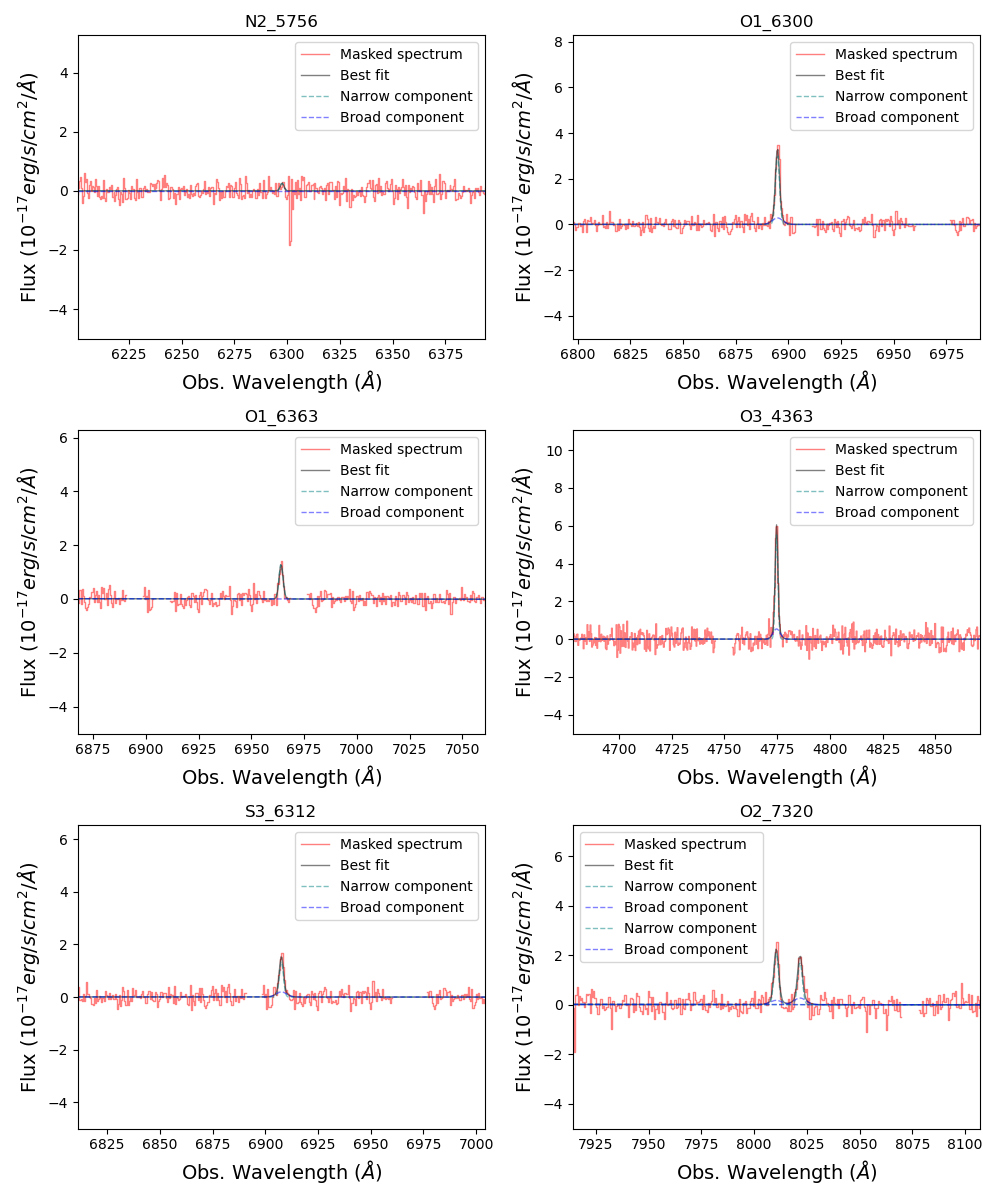

,sigma_v_narrow,sigma_v_broad,N2_5756_narrow_amplitude,N2_5756_broad_amplitude,O1_6300_narrow_amplitude,O1_6300_broad_amplitude,O1_6363_narrow_amplitude,O1_6363_broad_amplitude,O3_4363_narrow_amplitude,O3_4363_broad_amplitude,S3_6312_narrow_amplitude,S3_6312_broad_amplitude,O2_7320_narrow_amplitude,O2_7320_broad_amplitude,O2_7331_narrow_amplitude,O2_7331_broad_amplitude
0,41.229551,105.089196,0.570624,0.000001,7.298114,1.723255,3.101926,5.510581e-09,9.056629,2.268937,3.255155,1.178324,5.789,1.212285,4.836892,1.879808


In [4]:
red.fit_auroral(red.wave, red.flux, showplot=True)

In [5]:
df = red.fit_MC_auroral(numMC=100)

/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/lines.py:381: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  info = pd.concat([info, df], ignore_index=True)


Executed fit_MC_auroral in 18.1389s
